In [2]:
import torch
import torch.nn as nn
import torch.optim as optim 
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms, models



In [3]:
transform=transforms.Compose([transforms.ToTensor()])

In [4]:
train_data=datasets.MNIST(root='./DeepLearning',download=True, train=True,transform=transform)
test_data=datasets.MNIST(root='./DeepLearning',download= True,train=False,transform=transform)

In [5]:
train_dataloader=DataLoader(train_data,shuffle=True,batch_size=64)
test_dataloader=DataLoader(test_data,shuffle=False,batch_size=64)

In [10]:
class MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten=nn.Flatten()
        self.model=nn.Sequential(nn.Linear(784,128),nn.ReLU(),nn.Linear(128,10))
    def forward(self,x):
        x =self.flatten(x)
        l=self.model(x)
        return l
model=MNIST()
        
        

In [11]:
criterion=nn.CrossEntropyLoss()

In [12]:
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

In [13]:
for epoch in range(5):
    model.train()
    for images,labels in train_dataloader:
        output=model(images)
        loss=criterion(output,labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch{epoch+1}, Loss:{loss.item()}")

Epoch1, Loss:0.30761924386024475
Epoch2, Loss:0.14194409549236298
Epoch3, Loss:0.09120752662420273
Epoch4, Loss:0.14806295931339264
Epoch5, Loss:0.1266208440065384


In [14]:
output.shape

torch.Size([32, 10])

In [15]:
# Test with a small batch first
print(f"Model output shape: {output.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Label range: min={labels.min()}, max={labels.max()}")
print(f"Number of classes in model: {output.shape[1]}")

Model output shape: torch.Size([32, 10])
Labels shape: torch.Size([32])
Label range: min=0, max=9
Number of classes in model: 10


In [25]:
model.eval()
val_loss=0
correct=0
total=0

with torch.no_grad():
    for images, labels in test_dataloader:
        output= model(images)
        val_loss+= criterion(output,labels).item()
        _,predicted= torch.max(output.data,1)
        total+=labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct/total

print(f"Validation Loss:{val_loss/len(test_dataloader)}")
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Loss:0.08581601072156173
Validation Accuracy: 97.28%


tensor([2])


Actual Label 2
Predicted lable 2


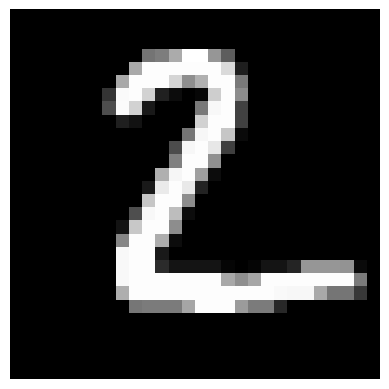

In [44]:
import matplotlib.pyplot as plt
image, label= test_data[1]
image=image.unsqueeze(0)

model.eval()

with torch.no_grad():
    output= model(image)
    _,predicted =torch.max(output,1)
print("Actual Label",label)
print("Predicted lable",predicted.item())

plt.imshow(image.squeeze(),cmap='gray')
plt.axis('off')
plt.show()

tensor([2])